# Environment Setup

In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
print(f"TensorFlow Version: {tf.version.VERSION}")

TensorFlow Version: 2.21.0


# Dynamic Path Configuration

In [10]:
# Update this path if running locally, or let it auto-detect on Kaggle
DATASET_PATH = Path(r"C:\Users\rajen\OneDrive\Desktop\Real_Time_FaceMask Detection\Face Mask Dataset")

TRAIN_DIR = DATASET_PATH / "Train"
VAL_DIR = DATASET_PATH / "Validation"
MODEL_SAVE_PATH = "mobilenet_finetuned_mask_model.keras"

IMG_SIZE = 224  # MobileNetV2 standard input size
BATCH_SIZE = 32
EPOCHS_HEAD = 5
EPOCHS_FINETUNE = 10

if not TRAIN_DIR.exists():
    raise FileNotFoundError(f"[ERROR] Could not find Train directory at {TRAIN_DIR}")
else:
    print(f"Dataset loaded successfully from {DATASET_PATH}")

Dataset loaded successfully from C:\Users\rajen\OneDrive\Desktop\Real_Time_FaceMask Detection\Face Mask Dataset


# Optimized Data Pipeline with MobileNetV2 Preprocessing

In [11]:
print("Building optimized data pipelines...")

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

CLASS_NAMES = train_ds.class_names
print(f"[INFO] Detected Classes (Alphabetical order): {CLASS_NAMES}")

# MobileNetV2 requires specific [-1, 1] scaling via preprocess_input
def normalization_layer(images, labels):
    return preprocess_input(images), labels

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(normalization_layer, num_parallel_calls=AUTOTUNE).cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.map(normalization_layer, num_parallel_calls=AUTOTUNE).cache().prefetch(buffer_size=AUTOTUNE)

Building optimized data pipelines...
Found 10000 files belonging to 2 classes.
Found 800 files belonging to 2 classes.
[INFO] Detected Classes (Alphabetical order): ['WithMask', 'WithoutMask']


# Building MobileNetV2 Transfer Learning Model

In [12]:
print("Initializing MobileNetV2 Base Model...")

# Load pre-trained MobileNetV2 without the top classification layer
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Phase 1: Freeze base model weights
base_model.trainable = False

# Construct custom classification head
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(len(CLASS_NAMES), activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Initializing MobileNetV2 Base Model...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Phase 1 Training (Training Classifier Head)

In [15]:
callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

print("Training Classification Head...")
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks_list
)

Training Classification Head...
Epoch 1/5


C:\Users\rajen\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


313/313 ━━━━━━━━━━━━━━━━━━━━ 138s 440ms/step - accuracy: 0.9955 - loss: 0.0133 - val_accuracy: 0.9987 - val_loss: 0.0029 - learning_rate: 0.0010
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 132s 422ms/step - accuracy: 0.9975 - loss: 0.0066 - val_accuracy: 1.0000 - val_loss: 8.8972e-04 - learning_rate: 0.0010
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 130s 417ms/step - accuracy: 0.9978 - loss: 0.0066 - val_accuracy: 0.9987 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 137s 437ms/step - accuracy: 0.9991 - loss: 0.0035 - val_accuracy: 0.9987 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 176s 564ms/step - accuracy: 0.9993 - loss: 0.0021 - val_accuracy: 0.9987 - val_loss: 0.0045 - learning_rate: 5.0000e-04


# Phase 2 Fine-Tuning (Unfreezing Top Layers)

In [16]:
print("Starting Fine-Tuning Phase...")

# Unfreeze the base model
base_model.trainable = True

# Freeze all layers except the last 30 layers for fine-tuning
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a very low learning rate for delicate fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINETUNE,
    callbacks=callbacks_list
)

# Save the finalized model artifact
model.save(MODEL_SAVE_PATH)
print(f"Fine-tuned model successfully saved to {MODEL_SAVE_PATH}")

Starting Fine-Tuning Phase...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 176s 533ms/step - accuracy: 0.9652 - loss: 0.1076 - val_accuracy: 0.9975 - val_loss: 0.0085 - learning_rate: 1.0000e-05
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 518s 2s/step - accuracy: 0.9938 - loss: 0.0171 - val_accuracy: 0.9975 - val_loss: 0.0060 - learning_rate: 1.0000e-05
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 181s 579ms/step - accuracy: 0.9971 - loss: 0.0077 - val_accuracy: 0.9987 - val_loss: 0.0033 - learning_rate: 1.0000e-05
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 184s 589ms/step - accuracy: 0.9985 - loss: 0.0051 - val_accuracy: 1.0000 - val_loss: 5.3289e-04 - learning_rate: 1.0000e-05
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 185s 592ms/step - accuracy: 0.9997 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 9.3444e-04 - learning_rate: 1.0000e-05
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 190s 607ms/step - accuracy: 0.9997 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 8.0089e-04 - learning_rate: 1.0000e-05
E

# Evaluation & Metrics Report

Evaluating Fine-Tuned Model...
CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    WithMask       1.00      1.00      1.00       400
 WithoutMask       1.00      1.00      1.00       400

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



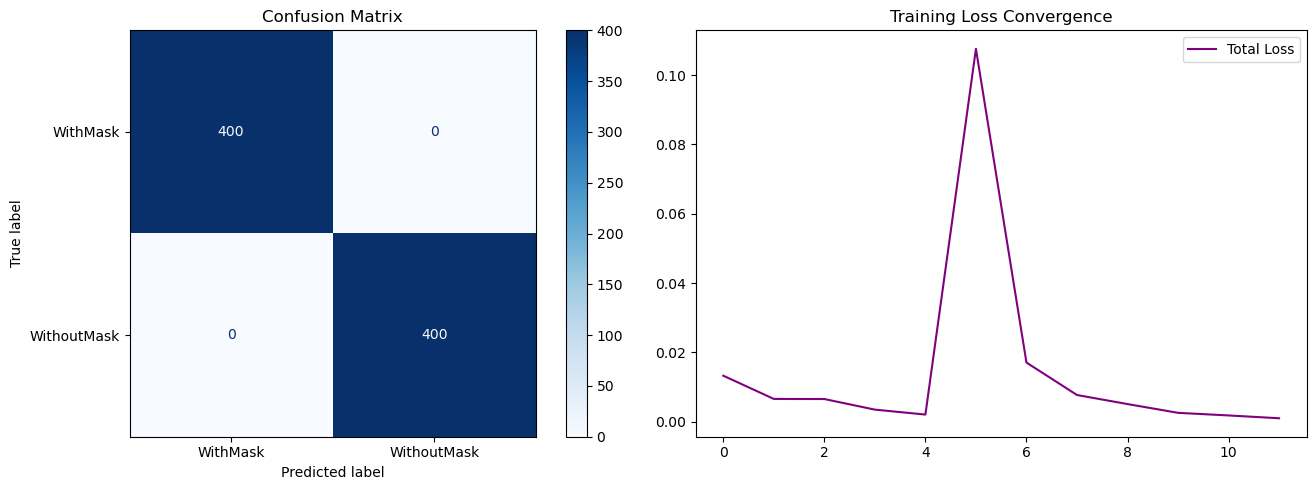

In [17]:
print("Evaluating Fine-Tuned Model...")

y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print("CLASSIFICATION REPORT:")

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap=plt.cm.Blues, ax=ax[0])
ax[0].set_title("Confusion Matrix")

# Combine history for visualization
combined_loss = history_head.history['loss'] + history_finetune.history['loss']
ax[1].plot(combined_loss, label='Total Loss', color='purple')
ax[1].set_title("Training Loss Convergence")
ax[1].legend()

plt.tight_layout()
plt.show()